In [ ]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import keras
from keras.datasets import mnist
from sklearn import preprocessing
import numpy as np

(train_xs, train_ys), (test_xs, test_ys) = mnist.load_data()
dim_x = train_xs.shape[1] * train_xs.shape[2]
dim_y = 10

train_xs = train_xs.reshape(train_xs.shape[0], dim_x).astype(np.float32)

scaler = preprocessing.MinMaxScaler().fit(train_xs)
train_xs = scaler.transform(train_xs)
print(train_xs.shape)
print(train_ys.shape)

11490434/11490434 [==============================] - 0s 0us/step
(60000, 784)
(60000,)


In [ ]:
ridx = np.random.randint(train_xs.shape[0], size=10000)
np_train_xs = train_xs[ridx, :]
np_train_ys = train_ys[ridx]
print(np_train_xs.shape)
print(np_train_ys.shape)

(10000, 784)
(10000,)


In [ ]:
%matplotlib inline
import sklearn
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style('darkgrid')
sns.set_palette('muted')
sns.set_context("notebook", font_scale=1.5, rc={"lines.linewidth": 2.5})

<ipython-input-5-bb164cddb7cc>:7: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  sc = ax.scatter(x[:,0], x[:,1], lw=0, s=540, c=palette[colors.astype(np.int)], alpha=0.2)


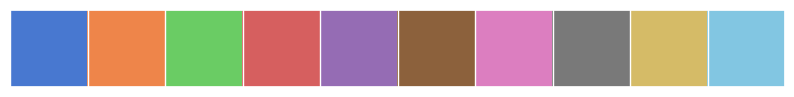

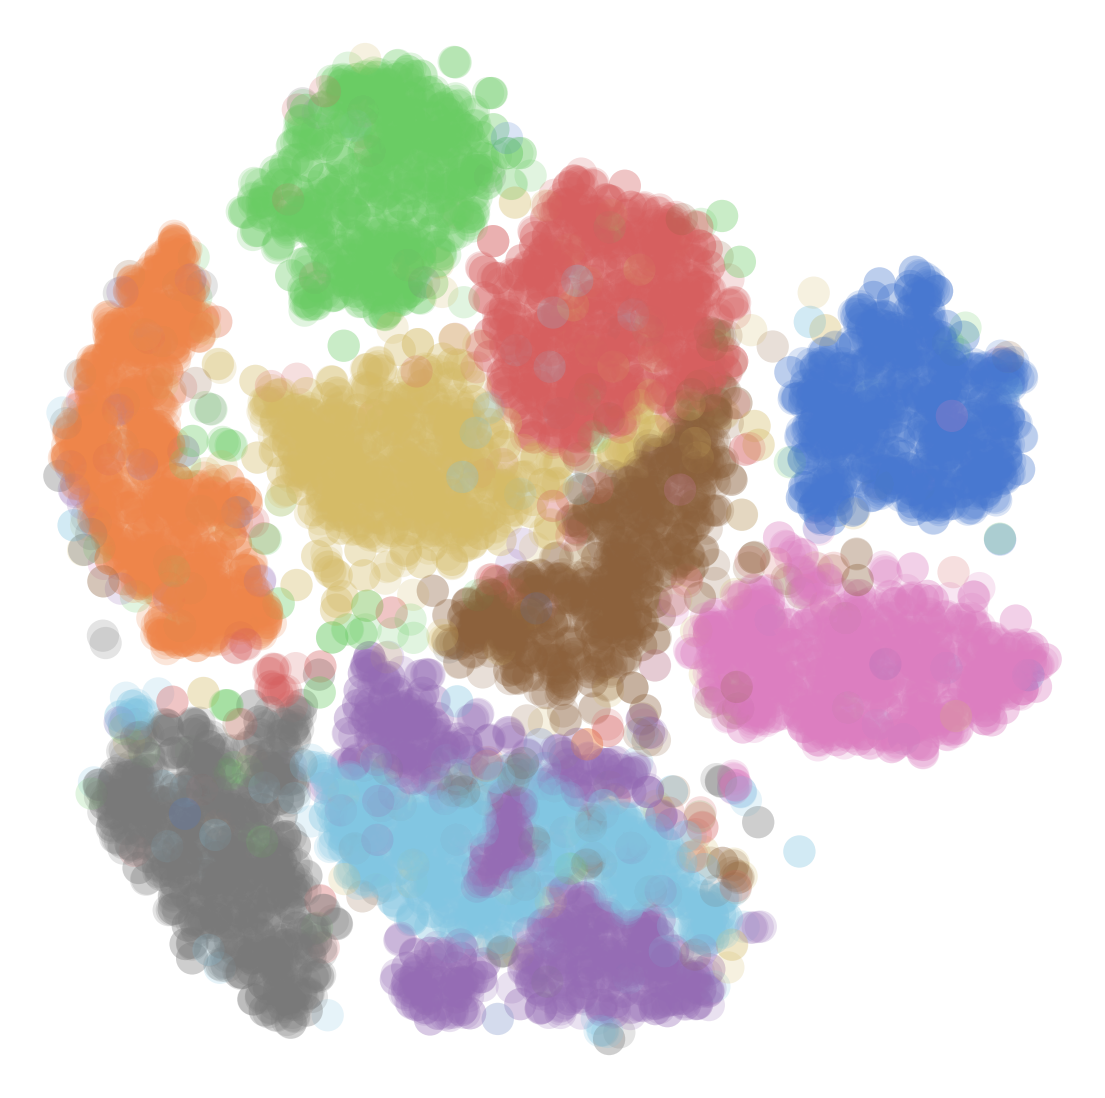

In [ ]:
def draw_scatter(x, n_class, colors):
    sns.palplot(sns.color_palette())
    palette = np.array(sns.color_palette())
    
    f = plt.figure(figsize=(14,14))
    ax = plt.subplot(aspect='equal')
    sc = ax.scatter(x[:,0], x[:,1], lw=0, s=540, c=palette[colors.astype(np.int)], alpha=0.2)
    plt.xlim(-25, 25)
    plt.ylim(-25, 25)
    ax.axis('off')
    ax.axis('tight')
    plt.show()
    
    
tsne_train_xs = TSNE(random_state=42).fit_transform(np_train_xs)
draw_scatter(tsne_train_xs, dim_y, np_train_ys)

<ipython-input-6-0a770bfd3e68>:13: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  ax.scatter(tsne_out[:,0], tsne_out[:,1], lw=0, s=25, c=palette[np_train_ys.astype(np.int)], alpha=0.3)
<ipython-input-6-0a770bfd3e68>:13: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release n

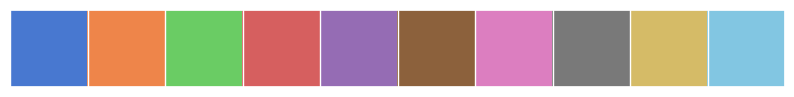

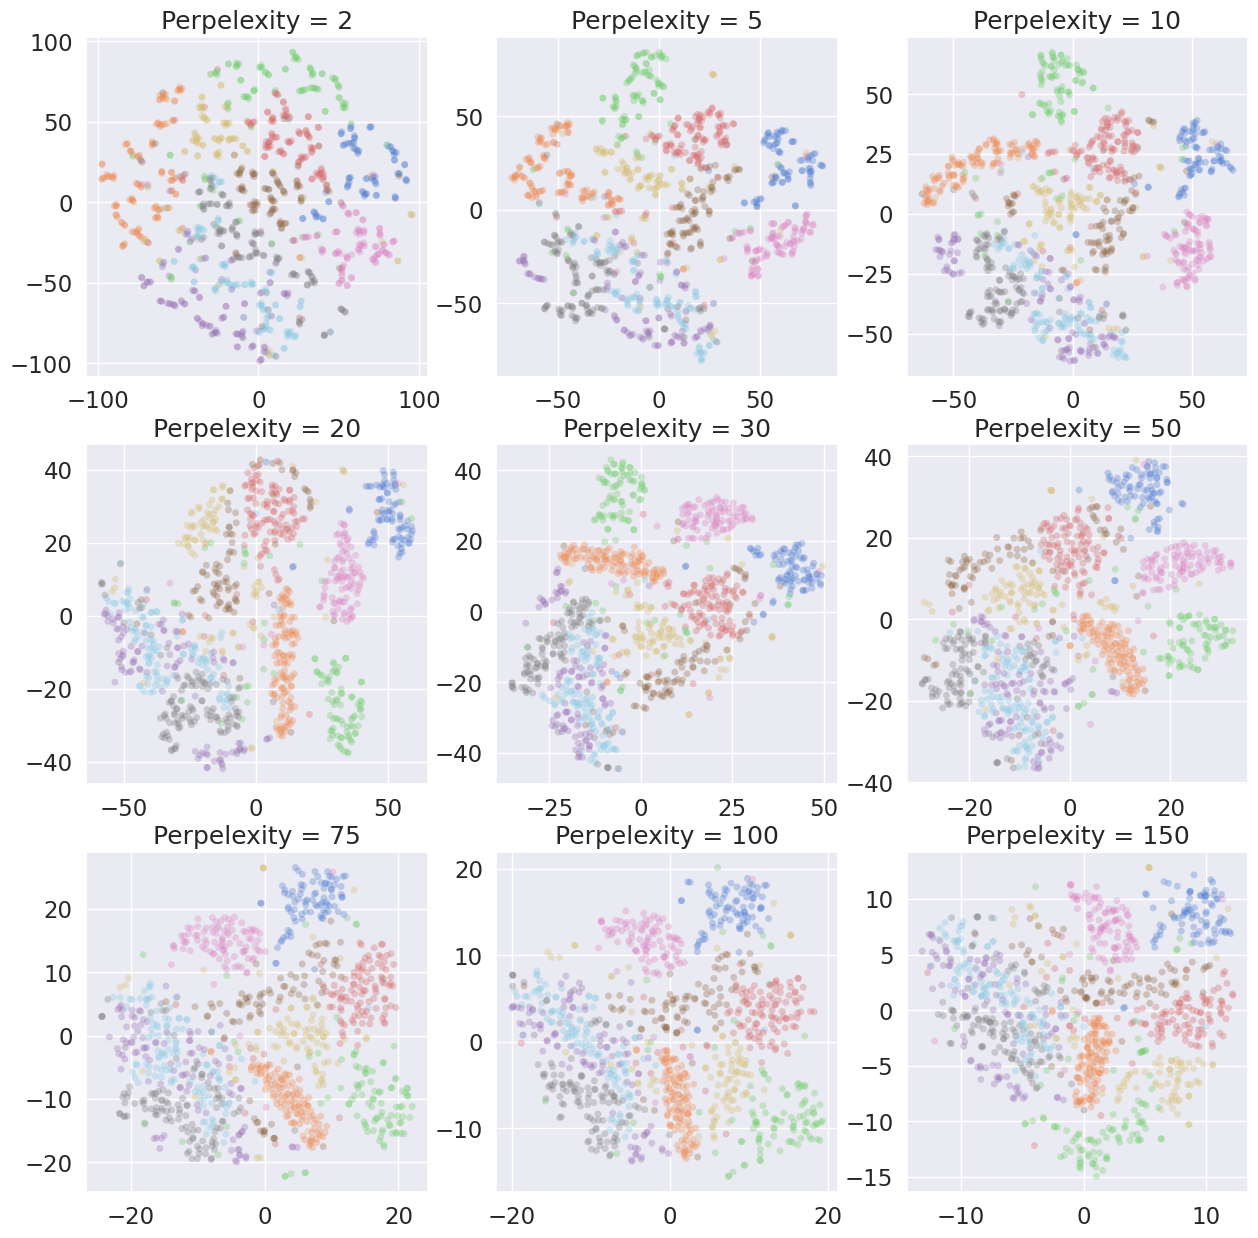

In [ ]:
ridx = np.random.randint(train_xs.shape[0], size = 1000) #data 크기를 줄임
np_train_xs = train_xs[ridx, :]
np_train_ys = train_ys[ridx]

sns.palplot(sns.color_palette()) # 숫자 0~9를 Color로 표시하여 보여줌
palette = np.array(sns.color_palette())
# 화면 구성은 3x3으로 보여줌
fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15,15))
for ax, perplexity in zip(axs.flat, [2,5,10,20,30,50,75,100,150]):
    tsne_out = TSNE(n_components = 2, perplexity = perplexity).fit_transform(np_train_xs)
    title = 'Perpelexity = {}'.format(perplexity)
    ax.set_title(title)
    ax.scatter(tsne_out[:,0], tsne_out[:,1], lw=0, s=25, c=palette[np_train_ys.astype(np.int)], alpha=0.3)
    ax.axis('tight')

plt.show()

In [2]:
from tensorflow.keras import datasets
from tensorflow.keras.utils import to_categorical
mnist = datasets.mnist
(train_x, train_y), (test_x, test_y) = mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


In [3]:
train_x = train_x.reshape(-1,784) 
test_x = test_x.reshape(-1,784) 
train_x = train_x / 255
test_x = test_x / 255


In [4]:
import sklearn
from sklearn.manifold import TSNE
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
tsne_train_xs = TSNE(n_components = 2, perplexity = 100).fit_transform(test_x)

In [9]:
tsne_train_xs.shape, test_x.shape, test_y.shape

((10000, 2), (10000, 784), (10000,))

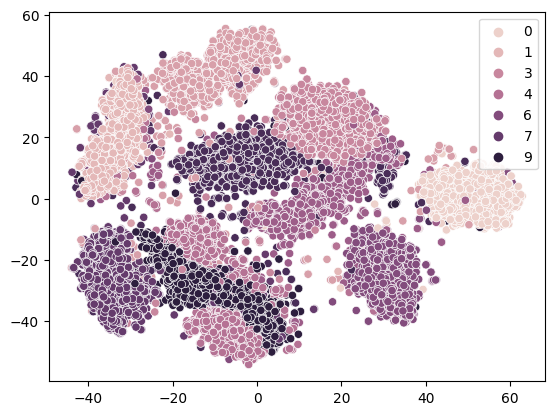

In [10]:
sns.scatterplot(x=tsne_train_xs[:,0], y=tsne_train_xs[:,1], hue=test_y)
plt.show()